In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

Tc = 2 / np.log(1 + np.sqrt(2))   # exact 2D Ising critical temperature
L_values = [10, 20, 30, 40, 60]
L_values_tri = [20, 30, 40, 60]

MODEL_DIR = '../models_100_op'
DATA_DIR  = '../data_test_4'
DATA_DIR_TRI = '../tri_uploaded'

# Markers and colours matching the paper (light → dark with increasing L)
markers = ['x', '^', 'o', 'D', 's']
blues   = ['#c6dbef', '#9ecae1', '#6baed6', '#2171b5', '#08306b']   # ordered output
reds    = ['#fcbba1', '#fc9272', '#fb6a4a', '#cb181d', '#67000d']   # disordered output

In [2]:
results = {}

for L in L_values:
    data    = np.load(f'{DATA_DIR}/L{L}_ising.npz')
    T_all   = data['temperatures']
    cfg_all = data['spins'].astype(np.float32)

    model = tf.keras.models.load_model(f'{MODEL_DIR}/ising_classifier_L{L}.h5')
    preds = model.predict(cfg_all, batch_size=512, verbose=0)   # (100000, 2)
    # label convention: [0] = P(disordered, T>Tc), [1] = P(ordered, T<Tc)
    out_ord = preds[:, 1]
    out_dis = preds[:, 0]

    unique_T = np.unique(T_all)
    mean_ord, err_ord = [], []
    mean_dis, err_dis = [], []
    for t in unique_T:
        mask = T_all == t
        n    = mask.sum()
        o = out_ord[mask];  mean_ord.append(o.mean());  err_ord.append(1.96 * o.std(ddof=1) / np.sqrt(n))
        d = out_dis[mask];  mean_dis.append(d.mean());  err_dis.append(1.96 * d.std(ddof=1) / np.sqrt(n))

    results[L] = {
        'T':             unique_T,
        'ordered':       np.array(mean_ord),
        'ordered_err':   np.array(err_ord),
        'disordered':    np.array(mean_dis),
        'disordered_err': np.array(err_dis),
    }
    print(f'L={L}: {len(unique_T)} temperatures, {(T_all == unique_T[0]).sum()} samples/temp')

L=10: 100 temperatures, 2500 samples/temp


L=20: 100 temperatures, 2500 samples/temp


L=30: 100 temperatures, 2500 samples/temp


L=40: 100 temperatures, 2500 samples/temp


L=60: 100 temperatures, 2500 samples/temp


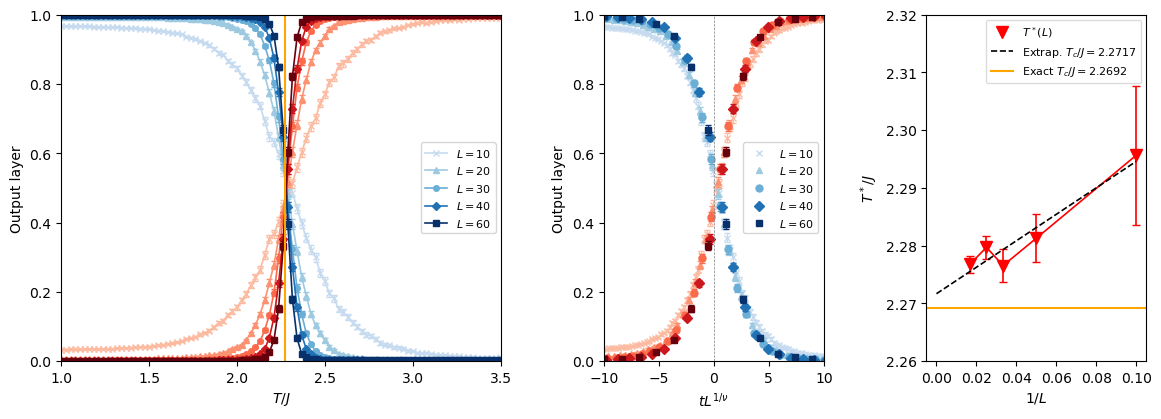

Extrapolated Tc (1/L→0): 2.2717   exact: 2.2692


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), gridspec_kw={'width_ratios': [2, 1, 1]})
fig.subplots_adjust(wspace=0.35)

eb_kw = dict(fmt='none', capsize=2, lw=0.8)   # shared errorbar style

# ── Panel a: output layer vs T/J ─────────────────────────────────────────
ax = axes[0]
for i, L in enumerate(L_values):
    T = results[L]['T']
    ax.plot(T, results[L]['ordered'],    color=blues[i], marker=markers[i], ms=4, lw=1.2, label=f'$L={L}$')
    ax.errorbar(T, results[L]['ordered'],    yerr=results[L]['ordered_err'],    ecolor=blues[i], **eb_kw)
    ax.plot(T, results[L]['disordered'], color=reds[i],  marker=markers[i], ms=4, lw=1.2)
    ax.errorbar(T, results[L]['disordered'], yerr=results[L]['disordered_err'], ecolor=reds[i],  **eb_kw)
ax.axvline(Tc, color='orange', lw=1.5)
ax.set_xlim(1.0, 3.5)
ax.set_ylim(0, 1)
ax.set_xlabel('$T/J$')
ax.set_ylabel('Output layer')
ax.legend(fontsize=8, loc='center right')

# ── Panel b: data collapse, t = T - Tc, nu = 1 ───────────────────────────
ax = axes[1]
nu = 1.0
for i, L in enumerate(L_values):
    T = results[L]['T']
    x = (T - Tc) * L ** (1 / nu)
    ax.plot(x, results[L]['ordered'],    color=blues[i], marker=markers[i], ms=5, lw=0, label=f'$L={L}$')
    ax.errorbar(x, results[L]['ordered'],    yerr=results[L]['ordered_err'],    ecolor=blues[i], **eb_kw)
    ax.plot(x, results[L]['disordered'], color=reds[i],  marker=markers[i], ms=5, lw=0)
    ax.errorbar(x, results[L]['disordered'], yerr=results[L]['disordered_err'], ecolor=reds[i],  **eb_kw)
ax.axvline(0, color='grey', lw=0.5, linestyle='--')
ax.set_xlim(-10, 10)
ax.set_ylim(0, 1)
ax.set_xlabel('$tL^{1/\\nu}$')
ax.set_ylabel('Output layer')
ax.legend(fontsize=8, loc='center right')

# ── Panel c: crossing temperature T* vs 1/L ───────────────────────────────
ax = axes[2]
T_star = []
for L in L_values:
    T       = results[L]['T']
    ord_out = results[L]['ordered']
    try:
        f     = interp1d(ord_out[::-1], T[::-1])
        Tstar = float(f(0.5))
    except Exception:
        Tstar = np.nan
    T_star.append(Tstar)

inv_L  = 1 / np.array(L_values)
T_star = np.array(T_star)

T_star_err = []
for L in L_values:
    T       = results[L]['T']
    ord_out = results[L]['ordered']
    ord_err = results[L]['ordered_err']
    Tstar = T_star[L_values.index(L)]
    err_at_Tstar = float(interp1d(T, ord_err, bounds_error=False)(Tstar))
    slope_local = float(interp1d(T[:-1], np.diff(ord_out) / np.diff(T), bounds_error=False)(Tstar))
    T_star_err.append(err_at_Tstar / abs(slope_local))
T_star_err = np.array(T_star_err)

ax.plot(inv_L, T_star, 'v', color='red', ms=8, zorder=3, label=r'$T^*(L)$')
ax.plot(inv_L, T_star, '-', color='red', lw=1.2)
ax.errorbar(inv_L, T_star, yerr=T_star_err, fmt='none', ecolor='red', capsize=3, lw=1.2)

slope, intercept = np.polyfit(inv_L, T_star, 1)
x_fit = np.linspace(0, inv_L.max(), 100)
ax.plot(x_fit, np.polyval([slope, intercept], x_fit), 'k--', lw=1.2,
        label=fr'Extrap. $T_c/J = {intercept:.4f}$')

ax.axhline(Tc, color='orange', lw=1.5, zorder=0,
           label=fr'Exact $T_c/J = {Tc:.4f}$')

ax.set_xlim(-0.005, 0.105)
ax.set_ylim(2.26, 2.32)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.set_xlabel('$1/L$')
ax.set_ylabel('$T^*/J$')
ax.legend(fontsize=8, loc='best', framealpha=0.7)

plt.savefig('figure1_abc.pdf', bbox_inches='tight', dpi=150)
plt.show()
print(f'Extrapolated Tc (1/L→0): {intercept:.4f}   exact: {Tc:.4f}')

In [4]:
results_tri = {}

for L in L_values:
    data    = np.load(f'{DATA_DIR_TRI}/L{L}_tri.npz')
    T_all   = data['temperatures']
    cfg_all = data['spins'].astype(np.float32)

    model = tf.keras.models.load_model(f'{MODEL_DIR}/ising_classifier_L{L}.h5')
    preds = model.predict(cfg_all, batch_size=512, verbose=0)
    out_ord = preds[:, 1]
    out_dis = preds[:, 0]

    unique_T = np.unique(T_all)
    mean_ord, err_ord = [], []
    mean_dis, err_dis = [], []
    for t in unique_T:
        mask = T_all == t
        n    = mask.sum()
        o = out_ord[mask];  mean_ord.append(o.mean());  err_ord.append(1.96 * o.std() / np.sqrt(n))
        d = out_dis[mask];  mean_dis.append(d.mean());  err_dis.append(1.96 * d.std() / np.sqrt(n))

    results_tri[L] = {
        'T':             unique_T,
        'ordered':       np.array(mean_ord),
        'ordered_err':   np.array(err_ord),
        'disordered':    np.array(mean_dis),
        'disordered_err': np.array(err_dis),
    }
    print(f'L={L}: {len(unique_T)} temperatures, {(T_all == unique_T[0]).sum()} samples/temp')

L=10: 41 temperatures, 250 samples/temp
L=20: 41 temperatures, 250 samples/temp
L=30: 41 temperatures, 250 samples/temp


L=40: 41 temperatures, 250 samples/temp
L=60: 41 temperatures, 250 samples/temp


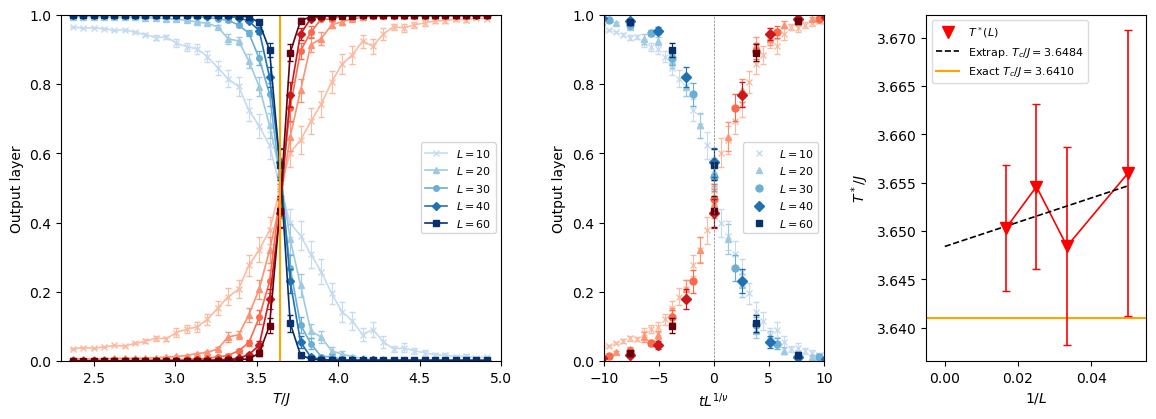

In [10]:
Tc_tri = 4 / np.log(3)   # exact triangular Ising critical temperature ≈ 3.641

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), gridspec_kw={'width_ratios': [2, 1, 1]})
fig.subplots_adjust(wspace=0.35)

eb_kw = dict(fmt='none', capsize=2, lw=0.8)

# ── Panel d: output layer vs T/J ─────────────────────────────────────────
ax = axes[0]
for i, L in enumerate(L_values):
    T = results_tri[L]['T']
    ax.plot(T, results_tri[L]['ordered'],    color=blues[i], marker=markers[i], ms=4, lw=1.2, label=f'$L={L}$')
    ax.errorbar(T, results_tri[L]['ordered'],    yerr=results_tri[L]['ordered_err'],    ecolor=blues[i], **eb_kw)
    ax.plot(T, results_tri[L]['disordered'], color=reds[i],  marker=markers[i], ms=4, lw=1.2)
    ax.errorbar(T, results_tri[L]['disordered'], yerr=results_tri[L]['disordered_err'], ecolor=reds[i],  **eb_kw)
ax.axvline(Tc_tri, color='orange', lw=1.5)
ax.set_xlim(2.3, 5)
ax.set_ylim(0, 1)
ax.set_xlabel('$T/J$')
ax.set_ylabel('Output layer')
ax.legend(fontsize=8, loc='center right')

# ── Panel e: data collapse ────────────────────────────────────────────────
ax = axes[1]
nu = 1.0
for i, L in enumerate(L_values):
    T = results_tri[L]['T']
    x = (T - Tc_tri) * L ** (1 / nu)
    ax.plot(x, results_tri[L]['ordered'],    color=blues[i], marker=markers[i], ms=5, lw=0, label=f'$L={L}$')
    ax.errorbar(x, results_tri[L]['ordered'],    yerr=results_tri[L]['ordered_err'],    ecolor=blues[i], **eb_kw)
    ax.plot(x, results_tri[L]['disordered'], color=reds[i],  marker=markers[i], ms=5, lw=0)
    ax.errorbar(x, results_tri[L]['disordered'], yerr=results_tri[L]['disordered_err'], ecolor=reds[i],  **eb_kw)
ax.axvline(0, color='grey', lw=0.5, linestyle='--')
ax.set_xlim(-10, 10)
ax.set_ylim(0, 1)
ax.set_xlabel('$tL^{1/\\nu}$')
ax.set_ylabel('Output layer')
ax.legend(fontsize=8, loc='center right')

# ── Panel f: crossing temperature T* vs 1/L ──────────────────────────────
ax = axes[2]
T_star_tri = []
for L in L_values_tri:
    T       = results_tri[L]['T']
    ord_out = results_tri[L]['ordered']
    try:
        f     = interp1d(ord_out[::-1], T[::-1])
        Tstar = float(f(0.5))
    except Exception:
        Tstar = np.nan
    T_star_tri.append(Tstar)

inv_L      = 1 / np.array(L_values_tri)
T_star_tri = np.array(T_star_tri)

T_star_tri_err = []
for L in L_values_tri:
    T       = results_tri[L]['T']
    ord_out = results_tri[L]['ordered']
    ord_err = results_tri[L]['ordered_err']
    Tstar = T_star_tri[L_values_tri.index(L)]
    err_at_Tstar = float(interp1d(T, ord_err, bounds_error=False)(Tstar))
    slope_local = float(interp1d(T[:-1], np.diff(ord_out) / np.diff(T), bounds_error=False)(Tstar))
    T_star_tri_err.append(err_at_Tstar / abs(slope_local))
T_star_tri_err = np.array(T_star_tri_err)

ax.plot(inv_L, T_star_tri, 'v', color='red', ms=8, zorder=3, label=r'$T^*(L)$')
ax.plot(inv_L, T_star_tri, '-', color='red', lw=1.2)
ax.errorbar(inv_L, T_star_tri, yerr=T_star_tri_err, fmt='none', ecolor='red', capsize=3, lw=1.2)

valid = ~np.isnan(T_star_tri)
if valid.sum() >= 2:
    slope, intercept = np.polyfit(inv_L[valid], T_star_tri[valid], 1)
    x_fit = np.linspace(0, inv_L.max(), 100)
    ax.plot(x_fit, np.polyval([slope, intercept], x_fit), 'k--', lw=1.2,
            label=fr'Extrap. $T_c/J = {intercept:.4f}$')

ax.axhline(Tc_tri, color='orange', lw=1.5, zorder=0,
           label=fr'Exact $T_c/J = {Tc_tri:.4f}$')

ax.set_xlim(-0.005, 0.055)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.set_xlabel('$1/L$')
ax.set_ylabel('$T^*/J$')
ax.legend(fontsize=8, loc='best', framealpha=0.7)

plt.savefig('figure1_def.pdf', bbox_inches='tight', dpi=150)
plt.show()